# JAISP Data Coverage Map

Scans all tile directories under `data/` and shows:
- Rubin tile footprints (coloured by band completeness / tract)
- Euclid VIS footprints overlaid
- NO_DATA tiles flagged in red
- Summary statistics per tract

In [1]:
from __future__ import annotations
import sys, os
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection
import matplotlib.cm as cm

from astropy.wcs import WCS
from astropy.io.fits import Header

REPO_ROOT = Path('..').resolve()
DATA_DIR  = REPO_ROOT / 'data'
print('Data dir:', DATA_DIR)

Data dir: /home/shemmati/Work/Projects/JAISP/data


In [2]:
# ── WCS helpers ──────────────────────────────────────────────────────────────

def _wcs_from_rubin(wcs_hdr_obj) -> WCS | None:
    """Build astropy WCS from a Rubin npz wcs_hdr (dict or bytes)."""
    try:
        hdr_dict = wcs_hdr_obj.item() if hasattr(wcs_hdr_obj, 'item') else wcs_hdr_obj
        hdr = Header()
        for k, v in hdr_dict.items():
            try:
                hdr[k] = v
            except Exception:
                pass
        hdr['NAXIS'] = 2
        hdr['NAXIS1'] = 512
        hdr['NAXIS2'] = 512
        return WCS(hdr)
    except Exception:
        return None


def _wcs_from_euclid(wcs_str: str, shape: tuple) -> WCS | None:
    """Build astropy WCS from a Euclid npz wcs string."""
    try:
        w = WCS(Header.fromstring(str(wcs_str)))
        return w
    except Exception:
        return None


def tile_corners_radec(wcs: WCS, nx: int, ny: int) -> np.ndarray | None:
    """Return (4, 2) array of (RA, Dec) corner coordinates [BL, BR, TR, TL]."""
    if wcs is None:
        return None
    try:
        corners_px = np.array([[0, 0], [nx-1, 0], [nx-1, ny-1], [0, ny-1]], dtype=float)
        return wcs.pixel_to_world_values(corners_px[:, 0], corners_px[:, 1])
    except Exception:
        return None

In [3]:
# ── Scan all data directories ────────────────────────────────────────────────

NO_DATA_BIT = 256

def scan_directory(rubin_dir: Path, euclid_dir: Path | None, tract: str, patch: str | None) -> list[dict]:
    """Scan one Rubin tile directory and its paired Euclid directory."""
    records = []
    rubin_files = sorted(rubin_dir.glob('tile_x*_y*.npz'))
    
    for rf in rubin_files:
        try:
            d = np.load(rf, allow_pickle=True, mmap_mode='r')
        except Exception as e:
            print(f'  [warn] could not load {rf.name}: {e}')
            continue

        tile_id = rf.stem
        bands   = list(d['bands']) if 'bands' in d else []
        mask    = d['mask']
        no_data_frac = float(np.mean((mask & NO_DATA_BIT).astype(bool)))
        has_data = no_data_frac < 0.99

        ra  = float(d['ra_center'])  if 'ra_center'  in d else np.nan
        dec = float(d['dec_center']) if 'dec_center' in d else np.nan

        # Rubin tile corners via WCS
        wcs_r = _wcs_from_rubin(d['wcs_hdr']) if 'wcs_hdr' in d else None
        corners_r = tile_corners_radec(wcs_r, 512, 512)

        # Euclid paired tile
        euclid_file = None
        corners_e   = None
        euclid_bands = []
        if euclid_dir:
            ef = euclid_dir / f'{tile_id}_euclid.npz'
            if ef.exists():
                euclid_file = ef
                try:
                    ed = np.load(ef, allow_pickle=True, mmap_mode='r')
                    euclid_bands = [b for b in ['VIS','Y','J','H'] if f'img_{b}' in ed]
                    if 'wcs_VIS' in ed and 'img_VIS' in ed:
                        H, W = ed['img_VIS'].shape
                        wcs_e = _wcs_from_euclid(ed['wcs_VIS'], (H, W))
                        corners_e = tile_corners_radec(wcs_e, W, H)
                except Exception:
                    pass

        records.append(dict(
            tile_id      = tile_id,
            tract        = tract,
            patch        = patch or '-',
            ra           = ra,
            dec          = dec,
            bands        = bands,
            has_z        = 'z' in bands,
            n_bands      = len(bands),
            no_data_frac = no_data_frac,
            has_data     = has_data,
            corners_r    = corners_r,   # (ra_arr, dec_arr) each len 4, or None
            has_euclid   = euclid_file is not None,
            euclid_bands = euclid_bands,
            corners_e    = corners_e,
        ))

    return records


def discover_all_tiles(data_dir: Path) -> list[dict]:
    """Discover all tract/patch directories under data_dir and scan them."""
    all_records = []

    # ── Existing flat ECDFS dirs ──────────────────────────────────────────
    rubin_ecdfs  = data_dir / 'rubin_tiles_ecdfs'
    euclid_ecdfs = data_dir / 'euclid_tiles_ecdfs'
    if rubin_ecdfs.exists():
        recs = scan_directory(rubin_ecdfs, euclid_ecdfs if euclid_ecdfs.exists() else None,
                               tract='ecdfs', patch=None)
        all_records.extend(recs)
        print(f'  ecdfs: {len(recs)} tiles')

    # ── New tract directories: rubin_tiles_tract{N}/patch{P}/ ─────────────
    for rubin_tract_dir in sorted(data_dir.glob('rubin_tiles_tract*')):
        tract = rubin_tract_dir.name.replace('rubin_tiles_tract', '')
        euclid_tract_dir = data_dir / f'euclid_tiles_tract{tract}'

        # Sub-patch directories
        patch_dirs = sorted(rubin_tract_dir.glob('patch*'))
        if patch_dirs:
            for patch_dir in patch_dirs:
                patch = patch_dir.name
                recs = scan_directory(patch_dir,
                                       euclid_tract_dir if euclid_tract_dir.exists() else None,
                                       tract=tract, patch=patch)
                all_records.extend(recs)
                print(f'  tract {tract} / {patch}: {len(recs)} tiles')
        else:
            # Flat tract dir (no patches)
            recs = scan_directory(rubin_tract_dir,
                                   euclid_tract_dir if euclid_tract_dir.exists() else None,
                                   tract=tract, patch=None)
            all_records.extend(recs)
            print(f'  tract {tract}: {len(recs)} tiles')

    return all_records


print('Scanning data directories...')
tiles = discover_all_tiles(DATA_DIR)
print(f'\nTotal: {len(tiles)} tiles')

Scanning data directories...
  ecdfs: 144 tiles

Total: 144 tiles


In [4]:

# ── Summary statistics ───────────────────────────────────────────────────────

tracts = sorted({t['tract'] for t in tiles})
header = '{:<12} {:>6} {:>8} {:>10} {:>6} {}'.format('Tract','Total','HasData','HasEuclid','HasZ','Bands')
print(header)
print('-' * 60)
for tr in tracts:
    sub = [t for t in tiles if t['tract'] == tr]
    nd  = sum(1 for t in sub if t['has_data'])
    eu  = sum(1 for t in sub if t['has_euclid'] and t['has_data'])
    hz  = sum(1 for t in sub if t['has_z'] and t['has_data'])
    bds = sub[0]['bands'] if sub else []
    print('{:<12} {:>6} {:>8} {:>10} {:>6}  {}'.format(tr, len(sub), nd, eu, hz, bds))

print()
valid = [t for t in tiles if t['has_data']]
ras  = [t['ra']  for t in valid if np.isfinite(t['ra'])]
decs = [t['dec'] for t in valid if np.isfinite(t['dec'])]
if ras:
    print(f'RA  range : {min(ras):.4f} - {max(ras):.4f} deg')
    print(f'Dec range : {min(decs):.4f} - {max(decs):.4f} deg')


Tract         Total  HasData  HasEuclid   HasZ Bands
------------------------------------------------------------
ecdfs           144      144        144    144  ['u', 'g', 'r', 'i', 'z', 'y']

RA  range : 53.0956 - 53.2731 deg
Dec range : -28.1842 - -28.0276 deg


In [5]:
# ── Colour scheme ────────────────────────────────────────────────────────────

# One colour per tract; NO_DATA always red
TRACT_COLORS = {
    'ecdfs':  '#2166ac',   # blue  (original ECDFS data)
    '5063':   '#d6604d',   # red-orange
    '4848':   '#4dac26',   # green
    '4849':   '#b8007a',   # magenta
    '5064':   '#00a9a5',   # teal
}
DEFAULT_COLOR = '#999999'
NODATA_COLOR  = '#eeeeee'
EUCLID_COLOR  = '#f4a700'  # amber


def get_color(tile: dict) -> str:
    if not tile['has_data']:
        return NODATA_COLOR
    return TRACT_COLORS.get(tile['tract'], DEFAULT_COLOR)


def corners_to_polygon(corners) -> np.ndarray | None:
    """Convert (ra_arr, dec_arr) corner tuple to (4,2) xy array for Polygon."""
    if corners is None:
        return None
    try:
        ra, dec = corners
        return np.column_stack([ra, dec])  # (4, 2)
    except Exception:
        return None

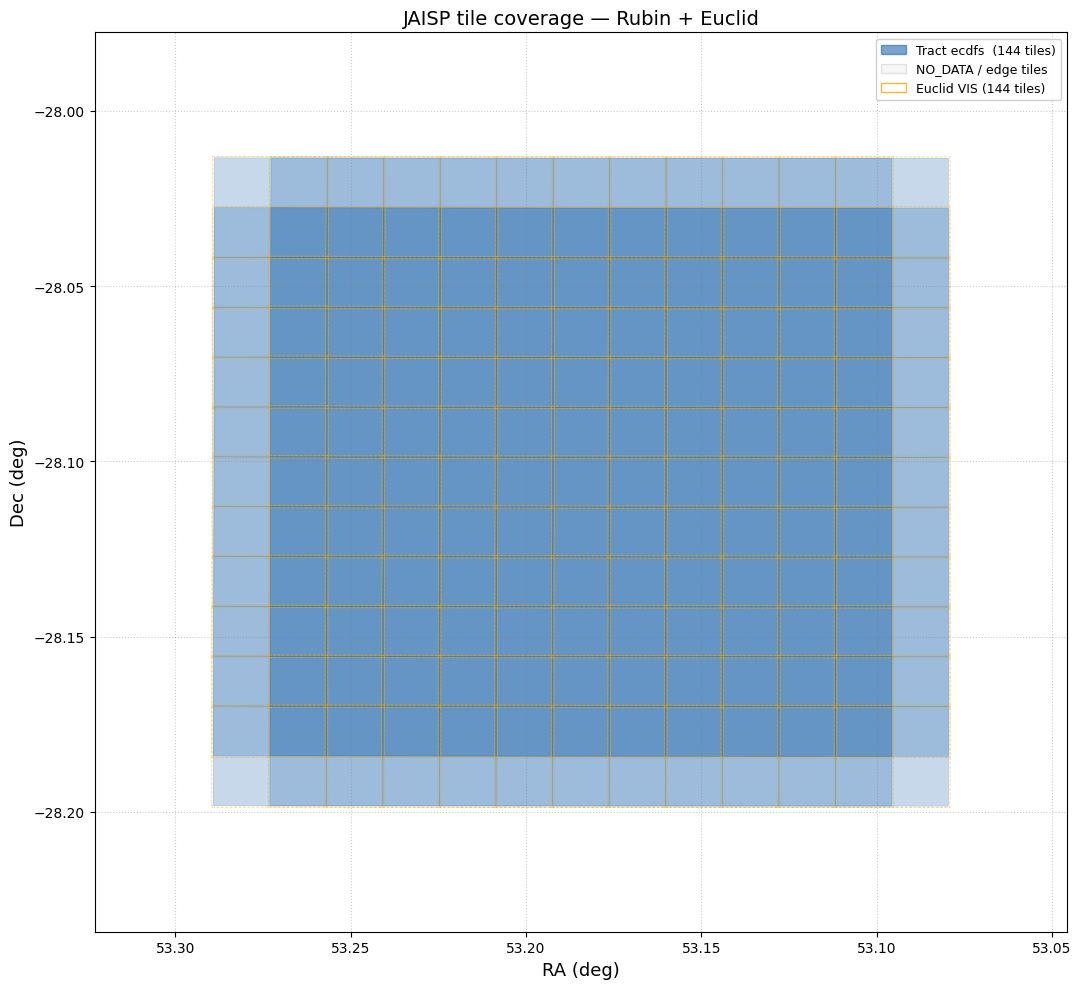

Saved → io/coverage_map.png


In [6]:
# ── Main coverage plot ───────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(12, 10))

# Draw Rubin tiles (filled, low alpha)
for tile in tiles:
    poly = corners_to_polygon(tile['corners_r'])
    if poly is None:
        # Fallback: approximate square from center
        if not np.isfinite(tile['ra']):
            continue
        d = 0.015  # ~54 arcsec
        poly = np.array([
            [tile['ra']-d, tile['dec']-d],
            [tile['ra']+d, tile['dec']-d],
            [tile['ra']+d, tile['dec']+d],
            [tile['ra']-d, tile['dec']+d],
        ])

    color = get_color(tile)
    alpha = 0.25 if tile['has_data'] else 0.08
    lw    = 0.5  if tile['has_data'] else 0.2
    ec    = color if tile['has_data'] else '#cccccc'

    patch = Polygon(poly, closed=True, fc=color, ec=ec, alpha=alpha, lw=lw)
    ax.add_patch(patch)

# Draw Euclid VIS footprints (outline only, amber)
euclid_tiles = [t for t in tiles if t['has_euclid'] and t['has_data']]
for tile in euclid_tiles:
    poly = corners_to_polygon(tile['corners_e'])
    if poly is None:
        continue
    patch = Polygon(poly, closed=True, fc='none', ec=EUCLID_COLOR, alpha=0.5, lw=0.6, ls='--')
    ax.add_patch(patch)

# ── Axes formatting ──────────────────────────────────────────────────────────
valid_ra  = [t['ra']  for t in tiles if np.isfinite(t['ra'])]
valid_dec = [t['dec'] for t in tiles if np.isfinite(t['dec'])]
if valid_ra:
    margin = 0.05
    ax.set_xlim(max(valid_ra)  + margin, min(valid_ra)  - margin)  # RA increases left
    ax.set_ylim(min(valid_dec) - margin, max(valid_dec) + margin)

ax.set_xlabel('RA (deg)', fontsize=13)
ax.set_ylabel('Dec (deg)', fontsize=13)
ax.set_title('JAISP tile coverage — Rubin + Euclid', fontsize=14)
ax.set_aspect('equal')
ax.grid(True, ls=':', alpha=0.4, color='gray')

# ── Legend ───────────────────────────────────────────────────────────────────
legend_handles = []
for tr in tracts:
    n = sum(1 for t in tiles if t['tract'] == tr and t['has_data'])
    color = TRACT_COLORS.get(tr, DEFAULT_COLOR)
    legend_handles.append(
        mpatches.Patch(fc=color, ec=color, alpha=0.6, label=f'Tract {tr}  ({n} tiles)')
    )
legend_handles.append(
    mpatches.Patch(fc=NODATA_COLOR, ec='#cccccc', alpha=0.5, label='NO_DATA / edge tiles')
)
legend_handles.append(
    mpatches.Patch(fc='none', ec=EUCLID_COLOR, alpha=0.8, label=f'Euclid VIS ({len(euclid_tiles)} tiles)')
)
ax.legend(handles=legend_handles, loc='upper right', fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.savefig(REPO_ROOT / 'io' / 'coverage_map.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → io/coverage_map.png')

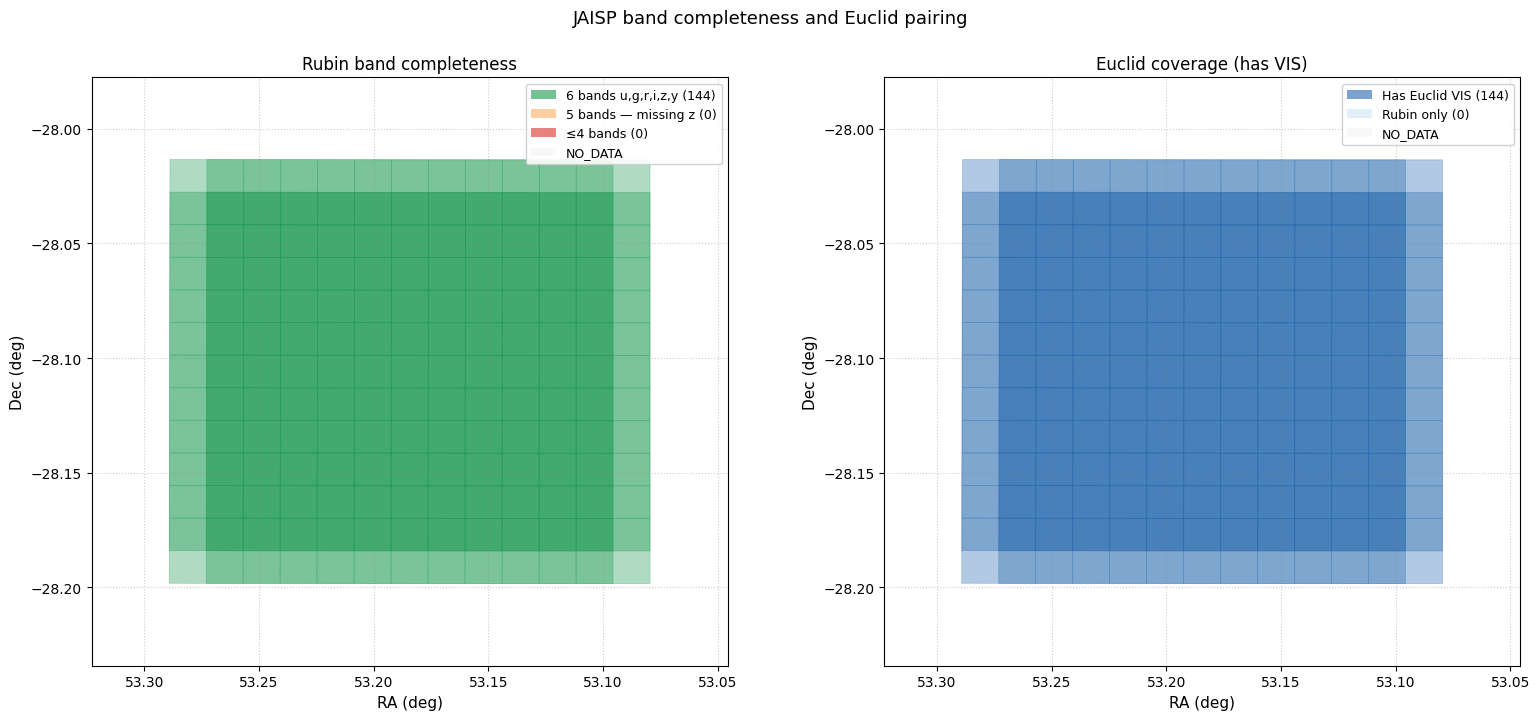

Saved → io/coverage_bands.png


In [7]:
# ── Band completeness detail plot ────────────────────────────────────────────
# Same footprints, now coloured by which Rubin bands are present

BAND_COLORS = {
    6: '#1a9850',   # full 6-band — green
    5: '#fdae61',   # 5-band (missing z typically) — orange
    4: '#d73027',   # 4-band — red
}

fig2, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, show_euclid, title in [
    (axes[0], False, 'Rubin band completeness'),
    (axes[1], True,  'Euclid coverage (has VIS)'),
]:
    for tile in tiles:
        poly = corners_to_polygon(tile['corners_r'])
        if poly is None:
            if not np.isfinite(tile['ra']):
                continue
            d = 0.015
            poly = np.array([
                [tile['ra']-d, tile['dec']-d], [tile['ra']+d, tile['dec']-d],
                [tile['ra']+d, tile['dec']+d], [tile['ra']-d, tile['dec']+d],
            ])

        if not tile['has_data']:
            color, alpha, lw = NODATA_COLOR, 0.08, 0.2
        elif show_euclid:
            color = '#2166ac' if tile['has_euclid'] else '#d1e5f0'
            alpha, lw = 0.35, 0.5
        else:
            color = BAND_COLORS.get(tile['n_bands'], '#666666')
            alpha, lw = 0.35, 0.5

        ax.add_patch(Polygon(poly, closed=True, fc=color, ec=color, alpha=alpha, lw=lw))

    if valid_ra:
        ax.set_xlim(max(valid_ra)+margin, min(valid_ra)-margin)
        ax.set_ylim(min(valid_dec)-margin, max(valid_dec)+margin)
    ax.set_xlabel('RA (deg)', fontsize=11)
    ax.set_ylabel('Dec (deg)', fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.set_aspect('equal')
    ax.grid(True, ls=':', alpha=0.4, color='gray')

    if show_euclid:
        has_eu = sum(1 for t in tiles if t['has_euclid'] and t['has_data'])
        no_eu  = sum(1 for t in tiles if not t['has_euclid'] and t['has_data'])
        handles = [
            mpatches.Patch(fc='#2166ac', alpha=0.6, label=f'Has Euclid VIS ({has_eu})'),
            mpatches.Patch(fc='#d1e5f0', alpha=0.6, label=f'Rubin only ({no_eu})'),
            mpatches.Patch(fc=NODATA_COLOR, alpha=0.4, label='NO_DATA'),
        ]
    else:
        n6 = sum(1 for t in tiles if t['n_bands']==6 and t['has_data'])
        n5 = sum(1 for t in tiles if t['n_bands']==5 and t['has_data'])
        n4 = sum(1 for t in tiles if t['n_bands']<=4 and t['has_data'])
        handles = [
            mpatches.Patch(fc=BAND_COLORS[6], alpha=0.6, label=f'6 bands u,g,r,i,z,y ({n6})'),
            mpatches.Patch(fc=BAND_COLORS[5], alpha=0.6, label=f'5 bands — missing z ({n5})'),
            mpatches.Patch(fc=BAND_COLORS[4], alpha=0.6, label=f'≤4 bands ({n4})'),
            mpatches.Patch(fc=NODATA_COLOR,   alpha=0.4, label='NO_DATA'),
        ]
    ax.legend(handles=handles, loc='upper right', fontsize=9, framealpha=0.9)

plt.suptitle('JAISP band completeness and Euclid pairing', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(REPO_ROOT / 'io' / 'coverage_bands.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → io/coverage_bands.png')

In [8]:
# ── Per-tract detail: which patches exist and how complete they are ───────────

print('Tiles with data by tract/patch:')
print(f'{"Tract":<10} {"Patch":<8} {"#tiles":>7} {"#Euclid":>8} {"Bands"}')
print('-' * 55)

for tr in tracts:
    patches = sorted({t['patch'] for t in tiles if t['tract'] == tr})
    for pa in patches:
        sub = [t for t in tiles if t['tract']==tr and t['patch']==pa and t['has_data']]
        if not sub:
            continue
        eu = sum(1 for t in sub if t['has_euclid'])
        all_bands = sorted({b for t in sub for b in t['bands']})
        print(f'{tr:<10} {pa:<8} {len(sub):>7} {eu:>8}  {all_bands}')

Tiles with data by tract/patch:
Tract      Patch     #tiles  #Euclid Bands
-------------------------------------------------------
ecdfs      -            144      144  ['g', 'i', 'r', 'u', 'y', 'z']
